# Loading the Datasets

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Base path to My Drive
DATASET_PATH = "/content/drive/MyDrive"

# File paths
qqq_path = f"{DATASET_PATH}/options_eod_QQQ.csv"
spy_path = f"{DATASET_PATH}/options_eod_SPY.csv"

# Load into DataFrames
df = pd.read_csv(qqq_path)
df_spy = pd.read_csv(spy_path)

# Feature Engineering

Our machine learning model makes use of gradient-boosted trees to predict returns through features derived from the options data, which work as good indicators for our model due to their forward-looking nature.

In [3]:
def rolling_zscore(series, window=20):
    return (series - series.rolling(window).mean()) / series.rolling(window).std()

To ensure modularity and interpretability, all options-derived signals are implemented as subclasses of a common `FeatureGenerator` interface.

Each generator:
- Takes raw options data as input
- Produces a **daily aggregated feature set**
- Encodes a specific economic hypothesis

In [4]:
import numpy as np

class FeatureGenerator:
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def generate(self) -> pd.DataFrame:
        raise NotImplementedError

The following block captures **aggregate options market participation**, which serves as a proxy for investor sentiment and positioning.

Features include:
- Normalized total call/put volume
- Normalized total call/put open interest
- Daily percentage changes in the quantities

Values have been normalized with their one year mean, to capture spikes instead of dealing with absolute values.


In [5]:
# Capturing general sentiment through trade volumes and open interest
class FlowFeatures(FeatureGenerator):
    def generate(self):
        daily = self.df.groupby('tradeDate').agg({
            'callVolume': 'sum',
            'putVolume': 'sum',
            'callOpenInterest': 'sum',
            'putOpenInterest': 'sum'
        })

        for col in daily.columns:
            daily[f'{col}_chg'] = daily[col].pct_change()
            daily[f'{col}_norm'] = daily[col] / daily[col].rolling(252).mean()

        return daily[[c for c in daily.columns if c.endswith('_norm') or c.endswith('_chg')]]

The implied volatility is calculated using the Brenner–Subrahmanyam approximation at ATM options. The approximation is given by,

$$
C_{\text{ATM}} \approx \frac{S_0 \, \sigma \, \sqrt{T}}{\sqrt{2\pi}}.
$$

Engineered features include:
- Average ATM implied volatility - this acts as a proxy for the implied volatility of the underlying asset

Economic intuition:
- The level of ATM IV reflects expected future uncertainty

In [6]:
class VolSurfaceFeatures(FeatureGenerator):
    def generate(self):
        df = self.df
        df['T'] = df['dte'] / 252

        df_atm = df[
            ((df['delta'].between(0.45, 0.55)) |
             (df['delta'].between(-0.55, -0.45)))
        ]

        if df_atm.empty:
            df_atm = df

        df_atm['iv_approx'] = (
            df_atm['callValue'] /
            (0.4 * df_atm['spotPrice'] * np.sqrt(df_atm['T'] + 1e-8))
        )

        daily = df_atm.groupby('tradeDate').apply(lambda x: pd.Series({
            'iv_mean': x['iv_approx'].mean()
        }))

        for c in daily.columns:
            daily[f'{c}_norm'] = daily[c] / daily[c].rolling(252).mean()

        return daily[[c for c in daily.columns ]]

Put–call ratios are sentiment measures derived from options activity.

We compute multiple variants:
- Volume-based and open-interest-based ratios
- Near-term vs long-term expirations

Economic intuition:
- High put–call ratios typically indicate fear or hedging demand
- Near-term ratios are more reflective of short-horizon expectations
- Open interest ratios capture structural positioning rather than daily trading noise

Rolling z-scores are applied to isolate **extreme sentiment deviations**.


In [7]:
class PutCallFeatures(FeatureGenerator):
    """
    Daily put-call ratio features, with variants for near-term / long-term and ATM/OTM.
    """
    def generate(self):
        df = self.df

        # Define near-term and long-term expiries (e.g., <=30 DTE short-term)
        near_term = df['dte'] <= 30
        long_term = df['dte'] > 30

        daily = df.groupby('tradeDate').apply(lambda x: pd.Series({
            'pc_ratio_vol': x['putVolume'].sum() / (x['callVolume'].sum() + 1e-8),
            'pc_ratio_oi': x['putOpenInterest'].sum() / (x['callOpenInterest'].sum() + 1e-8),
            'pc_ratio_vol_near': x.loc[near_term, 'putVolume'].sum() / (x.loc[near_term, 'callVolume'].sum() + 1e-8),
            'pc_ratio_oi_near': x.loc[near_term, 'putOpenInterest'].sum() / (x.loc[near_term, 'callOpenInterest'].sum() + 1e-8),
            'pc_ratio_vol_long': x.loc[long_term, 'putVolume'].sum() / (x.loc[long_term, 'callVolume'].sum() + 1e-8),
            'pc_ratio_oi_long': x.loc[long_term, 'putOpenInterest'].sum() / (x.loc[long_term, 'callOpenInterest'].sum() + 1e-8),
        }))

        # # Normalize ratios
        for c in daily.columns:
            daily[f'{c}_z'] = rolling_zscore(daily[c], 20)

        return daily[[c for c in daily.columns]]# if '_z' in c]]

This feature measures the gap between:
- Market-implied volatility from ATM options
- Recent realized volatility of spot prices

Economic intuition:
- When implied volatility significantly exceeds realized volatility, it often reflects fear or risk premia
- Conversely, low implied volatility can signal complacency and vulnerability

The spread is standardized using a rolling z-score to capture relative extremes rather than absolute levels.

In [8]:
class IVRealizedSpreadFeatures(FeatureGenerator):
    def generate(self):
        df = self.df
        df['T'] = df['dte'] / 252

        # ATM IV approximation
        atm = df[(df['delta'].between(0.45, 0.55)) | (df['delta'].between(-0.55, -0.45))]
        atm['iv_approx'] = atm['callValue'] / (0.4 * atm['spotPrice'] * np.sqrt(atm['T'] + 1e-8))

        daily_iv = atm.groupby('tradeDate')['iv_approx'].mean()

        # Realized vol 20-day
        daily_spot = df.groupby('tradeDate')['spotPrice'].last()
        rv_20d = daily_spot.pct_change().rolling(20).std()

        spread = daily_iv - rv_20d
        spread_z = rolling_zscore(spread, 20)
        return spread_z.to_frame(name='iv_rv_spread_z')

This block captures contango vs backwardation dynamics in the options market using a simple and robust proxy:
- The price ratio of near-term to longer-term ATM options

Economic intuition:
- In normal conditions, longer-dated options trade at higher prices due to time value (Contango)
- Elevated near-term option prices indicate short-term risk or stress (Backwardation)

This feature provides a lightweight but effective signal of imminent market tension.


In [9]:
class VolTermStructureFeatures(FeatureGenerator):
    """
    Proxies for contango/backwardation using option prices across expiries.
    """
    def generate(self):
        df = self.df

        # Pick ATM strikes
        df_atm = df[(df['delta'].between(0.45, 0.55)) | (df['delta'].between(-0.55, -0.45))]

        daily = df_atm.groupby('tradeDate').apply(lambda x: pd.Series({
            # Simplest proxy: price ratio nearest vs next expiry
            'atm_price_ratio': (
                x.loc[x['dte'] == x['dte'].min(), 'callValue'].mean() /
                x.loc[x['dte'] == x['dte'].max(), 'callValue'].mean()
            )
        }))

        daily['atm_price_ratio_z'] = rolling_zscore(daily['atm_price_ratio'], 100)
        return daily[['atm_price_ratio_z']]

This block approximates dealer positioning using aggregated option greeks weighted by open interest.

Key features:
- Net gamma exposure (calls minus puts)
- Gamma–vega interaction proxy (aiming to capture sensitivity to short term jumps in underlying as well as sensitivity to long term changes in IV)

Economic intuition:
- Dealer gamma positioning influences hedging flows
- Positive dealer gamma tends to dampen volatility
- Negative dealer gamma can amplify price moves and trend persistence

Normalizing by long-term averages allows the model to detect **regime-level changes** in market microstructure.


In [10]:
class DealerFeatures(FeatureGenerator):
    def generate(self):
        daily = self.df.groupby('tradeDate').apply(
            lambda x: pd.Series({
                'gamma_net': (x['gamma'] * (x['callOpenInterest'] - x['putOpenInterest'])).sum(),
                'gamma_vega': (x['gamma'] * x['vega']).sum()
            })
        )

        for col in daily.columns:
            daily[f'{col}_norm'] = daily[col] / daily[col].rolling(252).mean()

        return daily[[c for c in daily.columns if c.endswith('_norm')]]

To provide context and improve robustness, we include a small set of traditional price-based features:
- Short-horizon returns
- Short- and medium-term realized volatility

These features:
- Anchor the model during periods when options signals weaken
- Help distinguish volatility-driven effects from directional momentum
- Improve generalization without dominating the options-derived signals

All features are normalized to maintain scale consistency.


In [11]:
class ControlFeatures(FeatureGenerator):
    def generate(self):
        df = self.df.groupby('tradeDate').agg({'spotPrice': 'last'})

        df['ret_1d'] = df['spotPrice'].pct_change()
        df['ret_5d'] = df['spotPrice'].pct_change(5)
        df['rv_5d'] = df['ret_1d'].rolling(5).std()
        df['rv_20d'] = df['ret_1d'].rolling(20).std()

        for c in ['ret_1d', 'ret_5d', 'rv_5d', 'rv_20d']:
            df[f'{c}_norm'] = df[c] / df[c].rolling(252).mean()

        return df[[c for c in df.columns if c!='spotPrice']] #if '_norm' in c]]

All feature generators are combined into a single daily feature matrix.

In [12]:
class OptionsFeatureEngine:
    def __init__(self, df: pd.DataFrame):
        self.df = df

        self.generators = [
            FlowFeatures(df),
            VolSurfaceFeatures(df),
            DealerFeatures(df),
            ControlFeatures(df),
            PutCallFeatures(df),
            IVRealizedSpreadFeatures(df),
            VolTermStructureFeatures(df)
        ]

    def generate(self) -> pd.DataFrame:
        features = [g.generate() for g in self.generators]
        X = pd.concat(features, axis=1)
        X = X.loc[:, ~X.columns.duplicated()]
        return X

# Model Construction

For each symbol, we construct:
- A daily feature matrix derived solely from same-day options data
- A next-day return target based on spot price movement

The prediction target for our model is:
- Next-day fractional return
- Aligned to ensure no look-ahead bias

This setup mirrors a realistic trading workflow where options data observed at market close is used to determine next-day exposure.

In [13]:

class SymbolDataset:
    def __init__(self, df: pd.DataFrame, symbol: str):
        self.symbol = symbol
        self.df = df.copy()

        daily = df.groupby('tradeDate').agg({'spotPrice': 'last'})
        self.y = (
            (daily['spotPrice'].shift(-1) - daily['spotPrice']) /
            daily['spotPrice']
        )

        self.X = OptionsFeatureEngine(df).generate()
        self.align()

    def align(self):
        common_idx = self.X.index.intersection(self.y.index)
        self.X = self.X.loc[common_idx].iloc[1:]
        self.y = self.y.loc[common_idx].iloc[1:]

We use a LightGBM regressor to map engineered features to next-day returns.

Rationale:
- Handles nonlinear interactions common in options data
- Robust to noisy and partially redundant features
- Naturally supports feature importance analysis

Model complexity is deliberately constrained (shallow trees, regularization, subsampling) to reduce overfitting and improve stability across regimes.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

class ReturnPredictor:
    def __init__(self):
        self.model = lgb.LGBMRegressor(
            n_estimators=1000,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42
        )
        self.feature_names = None

    def fit(self, X, y, X_val=None, y_val=None):
        self.feature_names = X.columns.tolist()

        eval_set = [(X_val, y_val)] if X_val is not None else None
        self.model.fit(
            X, y,
            eval_set=eval_set,
            callbacks=[lgb.early_stopping(50)] if eval_set else None
        )

    def predict(self, X):
        return pd.Series(self.model.predict(X), index=X.index)

    def feature_importances(self) -> pd.Series:
        return pd.Series(
            self.model.feature_importances_,
            index=self.feature_names
        ).sort_values(ascending=False)


#Trading Strategy

Predicted returns are converted into trading exposures using a volatility-adjusted scaling rule.

Key steps:
- Standardize predictions by recent residual volatility
- Apply a smooth nonlinearity (tanh) to limit extreme leverage
- Enforce strict exposure bounds of [-1.0, +1.5]

This approach:
- Increases exposure only when signal confidence is high
- Automatically gives weak signals during uncertain regimes
- Produces stable, continuous position sizing rather than binary trades


In [15]:
import shap
class MLStrategy:
    def __init__(self, predictor: ReturnPredictor):
        self.predictor = predictor
        self.explainer = None
        self.last_shap_values = None
        self.last_X = None

    # ============================
    # Strategy Execution
    # ============================
    def run(self, X, y):
        y_hat = self.predictor.predict(X)
        resid = y - y_hat

        sigma = resid.rolling(30).std().shift(1)
        z = y_hat / sigma

        exposure = np.tanh(z) * 1.5
        exposure = exposure.clip(-1, 1.5).fillna(0)

        df = pd.DataFrame({
            'y': y,
            'Exposure': exposure
        })

        df['Return'] = df['y'] * df['Exposure']
        df['Cumulative'] = (1 + df['Return']).cumprod()

        return df

    # ============================
    # LightGBM Feature Importance
    # ============================
    def plot_feature_importance(self, top_n=30):
        fi = self.predictor.feature_importances().head(top_n)

        plt.figure(figsize=(10, 5))
        fi[::-1].plot(kind='barh')
        plt.title(f"Top {top_n} Feature Importances (Gain)")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    def get_feature_importance(self) -> pd.Series:
        return self.predictor.feature_importances()

    # ============================
    # SHAP: Initialization
    # ============================
    def _init_shap(self, X):
        """
        Lazily initialize SHAP explainer.
        """
        if self.explainer is None:
            self.explainer = shap.TreeExplainer(self.predictor.model)

        self.last_X = X
        self.last_shap_values = self.explainer.shap_values(X)

    # ============================
    # SHAP: Global Summary Plot
    # ============================
    def plot_shap_summary(self, X, max_display=20):
        """
        Global SHAP summary (direction + magnitude).
        """
        self._init_shap(X)

        shap.summary_plot(
            self.last_shap_values,
            X,
            max_display=max_display,
            show=True
        )

    # ============================
    # SHAP: Bar Plot (Magnitude Only)
    # ============================
    def plot_shap_importance(self, X, max_display=20):
        """
        SHAP bar plot (global importance).
        """
        self._init_shap(X)

        shap.summary_plot(
            self.last_shap_values,
            X,
            plot_type="bar",
            max_display=max_display,
            show=True
        )

    # ============================
    # SHAP: Directional Dependence
    # ============================
    def plot_shap_dependence(self, feature_name, X):
        """
        Directional effect of a single feature.
        """
        self._init_shap(X)

        shap.dependence_plot(
            feature_name,
            self.last_shap_values,
            X,
            interaction_index=None,
            show=True
        )

    # ============================
    # SHAP: Rolling Stability Check
    # ============================
    def plot_rolling_shap_importance(self, X, window=60, top_n=5):
        """
        Detects feature decay / regime dependence.
        """
        self._init_shap(X)

        shap_df = pd.DataFrame(
            np.abs(self.last_shap_values),
            index=X.index,
            columns=X.columns
        )

        rolling = shap_df.rolling(window).mean()
        top_features = rolling.mean().sort_values(ascending=False).head(top_n).index

        rolling[top_features].plot(
            figsize=(12, 5),
            title="Rolling SHAP Importance"
        )
        plt.tight_layout()
        plt.show()

    # ============================
    # SHAP: Raw Values (Research)
    # ============================
    def get_shap_dataframe(self, X) -> pd.DataFrame:
        """
        Returns SHAP values as DataFrame.
        """
        self._init_shap(X)

        return pd.DataFrame(
            self.last_shap_values,
            index=X.index,
            columns=X.columns
        )


## Performance Metrics and Evaluation

Strategy performance is evaluated using:
- Annualized return and volatility
- Sharpe ratio
- Maximum drawdown
- Calmar ratio (primary objective metric)

In [16]:
def performance(df):
    r = df['Return']
    c = df['Cumulative']

    ann_ret = (1 + c.iloc[-1] - 1) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol

    dd = (c / c.cummax() - 1).min()
    calmar = ann_ret / abs(dd)

    return {
        'Ann Return': ann_ret,
        'Ann Vol': ann_vol,
        'Sharpe': sharpe,
        'Max DD': dd,
        'Calmar': calmar
    }


## Train–Test Split and Cross-Symbol Training

A single chronological split is used to preserve temporal structure and avoid leakage from future regimes.

QQQ and SPY are modeled jointly during training but evaluated independently.

In [17]:
# ============================
# Train / Test Split
# ============================
split_frac = 0.7
qqq = SymbolDataset(df, 'QQQ')
spy = SymbolDataset(df_spy, 'SPY')
# ---- QQQ ----
split_idx_qqq = int(len(qqq.X) * split_frac)

X_train_qqq = qqq.X.iloc[:split_idx_qqq]
X_test_qqq  = qqq.X.iloc[split_idx_qqq:]

y_train_qqq = qqq.y.iloc[:split_idx_qqq]
y_test_qqq  = qqq.y.iloc[split_idx_qqq:]


# ---- SPY ----
split_idx_spy = int(len(spy.X) * split_frac)

X_train_spy = spy.X.iloc[:split_idx_spy]
X_test_spy  = spy.X.iloc[split_idx_spy:]

y_train_spy = spy.y.iloc[:split_idx_spy]
y_test_spy  = spy.y.iloc[split_idx_spy:]


# ============================
# Combine Training Sets
# ============================
X_train = pd.concat([X_train_qqq, X_train_spy])
y_train = pd.concat([y_train_qqq, y_train_spy])


# ============================
# Train Model
# ============================
model = ReturnPredictor()
model.fit(X_train, y_train)

/tmp/ipython-input-3298490096.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_atm['iv_approx'] = (
/tmp/ipython-input-3298490096.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = df_atm.groupby('tradeDate').apply(lambda x: pd.Series({
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8344
[LightGBM] [Info] Number of data points in the train set: 2008, number of used features: 34
[LightGBM] [Info] Start training from score 0.000627
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

#Feature Importances

The following plot shows beeswarm plots of model features in order of their mean absolute shap values.

The
 displays each observation in the dataset as an individual point for every variable. Points are positioned horizontally based on their SHAP values, indicating both the direction and magnitude of each variable’s contribution to the model’s prediction. Where many observations share similar SHAP values, points are stacked vertically to reflect higher density. Examining this horizontal distribution reveals how strongly and consistently a variable influences predictions.

Point color represents the raw value of the variable, not the SHAP value. Relatively high feature values appear in red, while low values appear in blue. Observing how these colors align along the x-axis helps identify the relationship between a variable’s magnitude and its effect on the model output, such as whether higher values tend to increase or decrease predictions

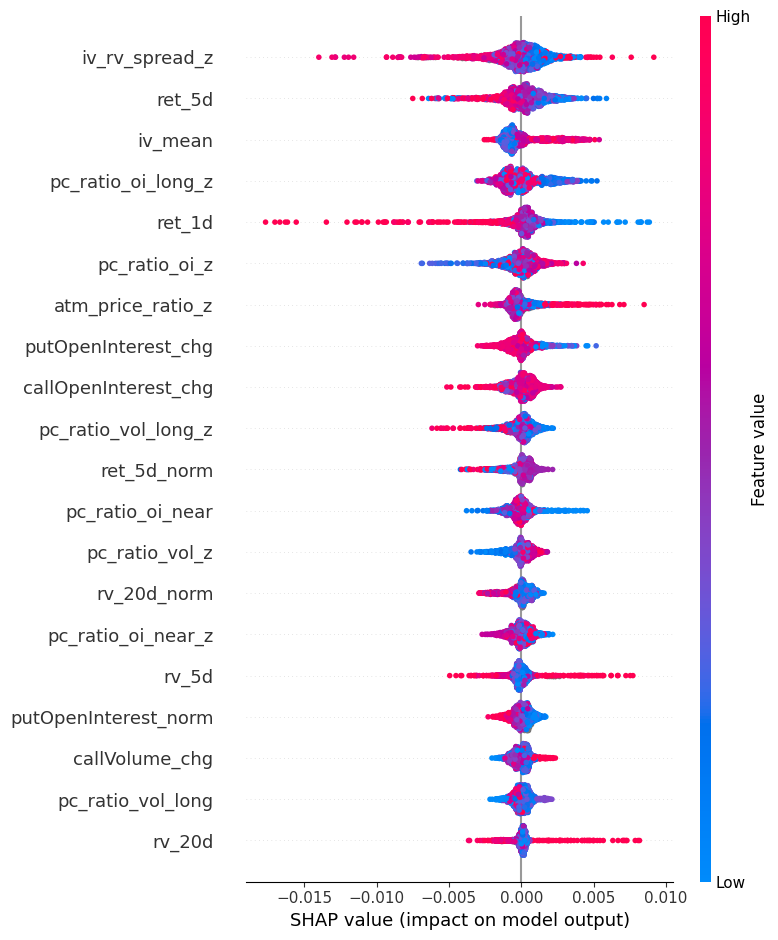

In [18]:

strategy = MLStrategy(model)
strategy.plot_shap_summary(X_train)

In [19]:
#Running the Trained Model
# ============================
# Run Strategy (Per Ticker)
# ============================
qqq_res = strategy.run(
    X_test_qqq.iloc[:-1],
    y_test_qqq.iloc[:-1]
)

spy_res = strategy.run(
    X_test_spy.iloc[:-1],
    y_test_spy.iloc[:-1]
)


#Backtesting

In [20]:
def performance_markdown(name, perf):
    return f"""
### {name} Strategy Performance

- Annual Return: {perf['Ann Return']:.2%}
- Annual Volatility: {perf['Ann Vol']:.2%}
- Sharpe Ratio: {perf['Sharpe']:.2f}
- Maximum Drawdown: {perf['Max DD']:.2%}
- Calmar Ratio: {perf['Calmar']:.2f}
"""

print(performance_markdown("QQQ", performance(qqq_res)))
print(performance_markdown("SPY", performance(spy_res)))


### QQQ Strategy Performance

- Annual Return: 25.61%
- Annual Volatility: 12.30%
- Sharpe Ratio: 2.08
- Maximum Drawdown: -5.00%
- Calmar Ratio: 5.12


### SPY Strategy Performance

- Annual Return: 11.85%
- Annual Volatility: 9.06%
- Sharpe Ratio: 1.31
- Maximum Drawdown: -4.72%
- Calmar Ratio: 2.51

